# Notebook 01 — EDA Dataset LSP + Baseline

**Lengua de Señas Peruana (LSP) — Sistema de Reconocimiento con Deep Learning**

Este notebook cubre:
1. Carga y verificación del dataset de videos MP4
2. **Estadísticas descriptivas** completas
3. **Distribución de variables clave** (clases, duración, FPS, resolución)
4. **Riesgos identificados**: leakage, desbalance, drift
5. **Baseline mínimo**: KNN + Logistic Regression con features de color/movimiento
6. Resultados, métricas y gráfica central
7. Exportación de manifest y label encoder

In [6]:
# ── Configuración de entorno (Colab o Local) ──────────────────────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    !pip install -q opencv-python-headless mediapipe pandas matplotlib seaborn tqdm scikit-learn
    BASE_DIR = '/content/drive/MyDrive/TRADUCTOR_LSP'
    VIDEO_DIR = '/content/drive/MyDrive/TRADUCTOR_LSP/data/videos/original'
else:
    BASE_DIR  = str(os.path.dirname(os.path.abspath('.')))  # raíz del proyecto
    VIDEO_DIR = os.path.join(BASE_DIR, 'data', 'videos', 'original')

DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Entorno: {"Colab" if IN_COLAB else "Local"}')
print(f'BASE_DIR: {BASE_DIR}')
print(f'VIDEO_DIR: {VIDEO_DIR}')

Entorno: Local
BASE_DIR: /Users/usuario/Documents/TRADUCTOR_LSP
VIDEO_DIR: /Users/usuario/Documents/TRADUCTOR_LSP/data/videos/original


In [7]:
import re, json, time, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 110
print('Imports OK ✓')

Imports OK ✓


## 1. Carga y Escaneo del Dataset

In [27]:
# Escanear todos los MP4
vdir = Path(VIDEO_DIR)
videos = sorted(list(vdir.glob('*.mp4')) + list(vdir.glob('*.MP4')))
print(f'Videos encontrados: {len(videos)}')
for v in videos[:5]:
    print(f'  {v.name}')
if len(videos) > 5:
    print(f'  ... y {len(videos)-5} más')

Videos encontrados: 26
  Historias vinetas (11).mp4
  Historias vinetas (12).mp4
  Historias vinetas (13).mp4
  Historias vinetas (14).mp4
  Historias vinetas (15).mp4
  ... y 21 más


In [28]:
# Extraer metadatos de cada video
records = []
for vp in tqdm(videos, desc='Extrayendo metadatos'):
    cap = cv2.VideoCapture(str(vp))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    dur = n_frames / fps if fps > 0 else 0
    match = re.search(r'\((\d+)\)', vp.stem)
    num   = int(match.group(1)) if match else -1
    records.append({
        'ruta':         str(vp),
        'nombre':       vp.name,
        'num_vineta':   num,
        'clase':        f'vineta_{num:03d}',
        'n_frames':     n_frames,
        'fps':          fps,
        'ancho':        width,
        'alto':         height,
        'resolucion':   f'{width}x{height}',
        'duracion_seg': round(dur, 2),
        'size_mb':      round(vp.stat().st_size / 1e6, 2),
        'valido':       n_frames > 0 and fps > 0,
    })

df = pd.DataFrame(records).sort_values('num_vineta').reset_index(drop=True)
df_v = df[df['valido']].copy()
print(f'\nDataFrame: {len(df)} videos | {len(df_v)} válidos')
df_v.head(8)

Extrayendo metadatos:   0%|          | 0/26 [00:00<?, ?it/s]


DataFrame: 26 videos | 26 válidos


,ruta,nombre,num_vineta,clase,n_frames,fps,ancho,alto,resolucion,duracion_seg,size_mb,valido
0,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (2).mp4,2,vineta_002,3045,29.941248,1920,1080,1920x1080,101.70,40.05,True
1,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (3).mp4,3,vineta_003,17071,29.970000,640,360,640x360,569.60,29.57,True
2,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (4).mp4,4,vineta_004,3525,29.950762,1920,1080,1920x1080,117.69,55.56,True
3,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (5).mp4,5,vineta_005,3900,29.970030,1920,1080,1920x1080,130.13,58.10,True
4,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (6).mp4,6,vineta_006,5835,29.970030,1920,1080,1920x1080,194.69,69.32,True
5,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (8).mp4,8,vineta_008,3510,29.945399,1920,1080,1920x1080,117.21,41.39,True
6,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (11).mp4,11,vineta_011,1800,29.970030,1920,1080,1920x1080,60.06,24.76,True
7,/Users/usuario/Documents/TRADUCTOR_LSP/data/vi...,Historias vinetas (12).mp4,12,vineta_012,2954,29.970000,640,480,640x480,98.57,16.18,True


## 2. Estadísticas Descriptivas

In [29]:
print('─'*55)
print('ESTADÍSTICAS DESCRIPTIVAS — DATASET LSP')
print('─'*55)
print(f'  Total videos:         {len(df_v)}')
print(f'  Clases únicas:        {df_v["clase"].nunique()}')
print(f'  Duración total:       {df_v["duracion_seg"].sum()/60:.1f} min')
print(f'  Frames totales:       {df_v["n_frames"].sum():,}')
print(f'  Tamaño total:         {df_v["size_mb"].sum():.0f} MB')
print()
print('  DURACIÓN (segundos):')
dur_stats = df_v['duracion_seg'].agg(['mean','std','min','median','max'])
for k, v in dur_stats.items():
    print(f'    {k:8s}: {v:.1f}s')
print()
print('  FPS:')
print(f'    Únicos: {sorted(df_v["fps"].unique())}')
print()
print('  RESOLUCIONES:')
for res, cnt in df_v['resolucion'].value_counts().items():
    pct = cnt/len(df_v)*100
    print(f'    {res:12s} → {cnt} videos ({pct:.0f}%)')
print()
# Segmentos potenciales con sliding window
segs = ((df_v['n_frames'] - 30) // 15).sum()
print(f'  Segmentos @30f stride15:  ~{segs:,}')
print(f'  Señas ~2s/seña est.:      ~{int(df_v["duracion_seg"].sum()/2):,}')

───────────────────────────────────────────────────────
ESTADÍSTICAS DESCRIPTIVAS — DATASET LSP
───────────────────────────────────────────────────────
  Total videos:         26
  Clases únicas:        26
  Duración total:       60.7 min
  Frames totales:       109,163
  Tamaño total:         744 MB

  DURACIÓN (segundos):
    mean    : 140.1s
    std     : 103.4s
    min     : 51.6s
    median  : 110.9s
    max     : 569.6s

  FPS:
    Únicos: [29.94124828948123, 29.9453987032192, 29.950761797272285, 29.97, 29.970000154493587, 29.97002997002997, 29.970085698546587, 29.9700909341379]

  RESOLUCIONES:
    640x480      → 16 videos (62%)
    1920x1080    → 7 videos (27%)
    1280x720     → 2 videos (8%)
    640x360      → 1 videos (4%)

  Segmentos @30f stride15:  ~7,218
  Señas ~2s/seña est.:      ~1,821


In [12]:
# Tabla descriptiva completa
desc = df_v[['duracion_seg','n_frames','fps','ancho','alto','size_mb']].describe().round(2)
print('Describe completo:')
display(desc)

Describe completo:


,duracion_seg,n_frames,fps,ancho,alto,size_mb
count,26.00,26.00,26.00,26.00,26.00,26.00
mean,140.10,4198.58,29.97,1033.85,655.38,28.61
std,103.43,3099.78,0.01,574.63,272.02,15.87
min,51.62,1547.00,29.94,640.00,360.00,8.51
25%,81.57,2444.50,29.97,640.00,480.00,16.36
50%,110.88,3321.50,29.97,640.00,480.00,26.04
75%,164.85,4940.75,29.97,1760.00,990.00,39.76
max,569.60,17071.00,29.97,1920.00,1080.00,69.32


## 3. Distribución de Variables Clave

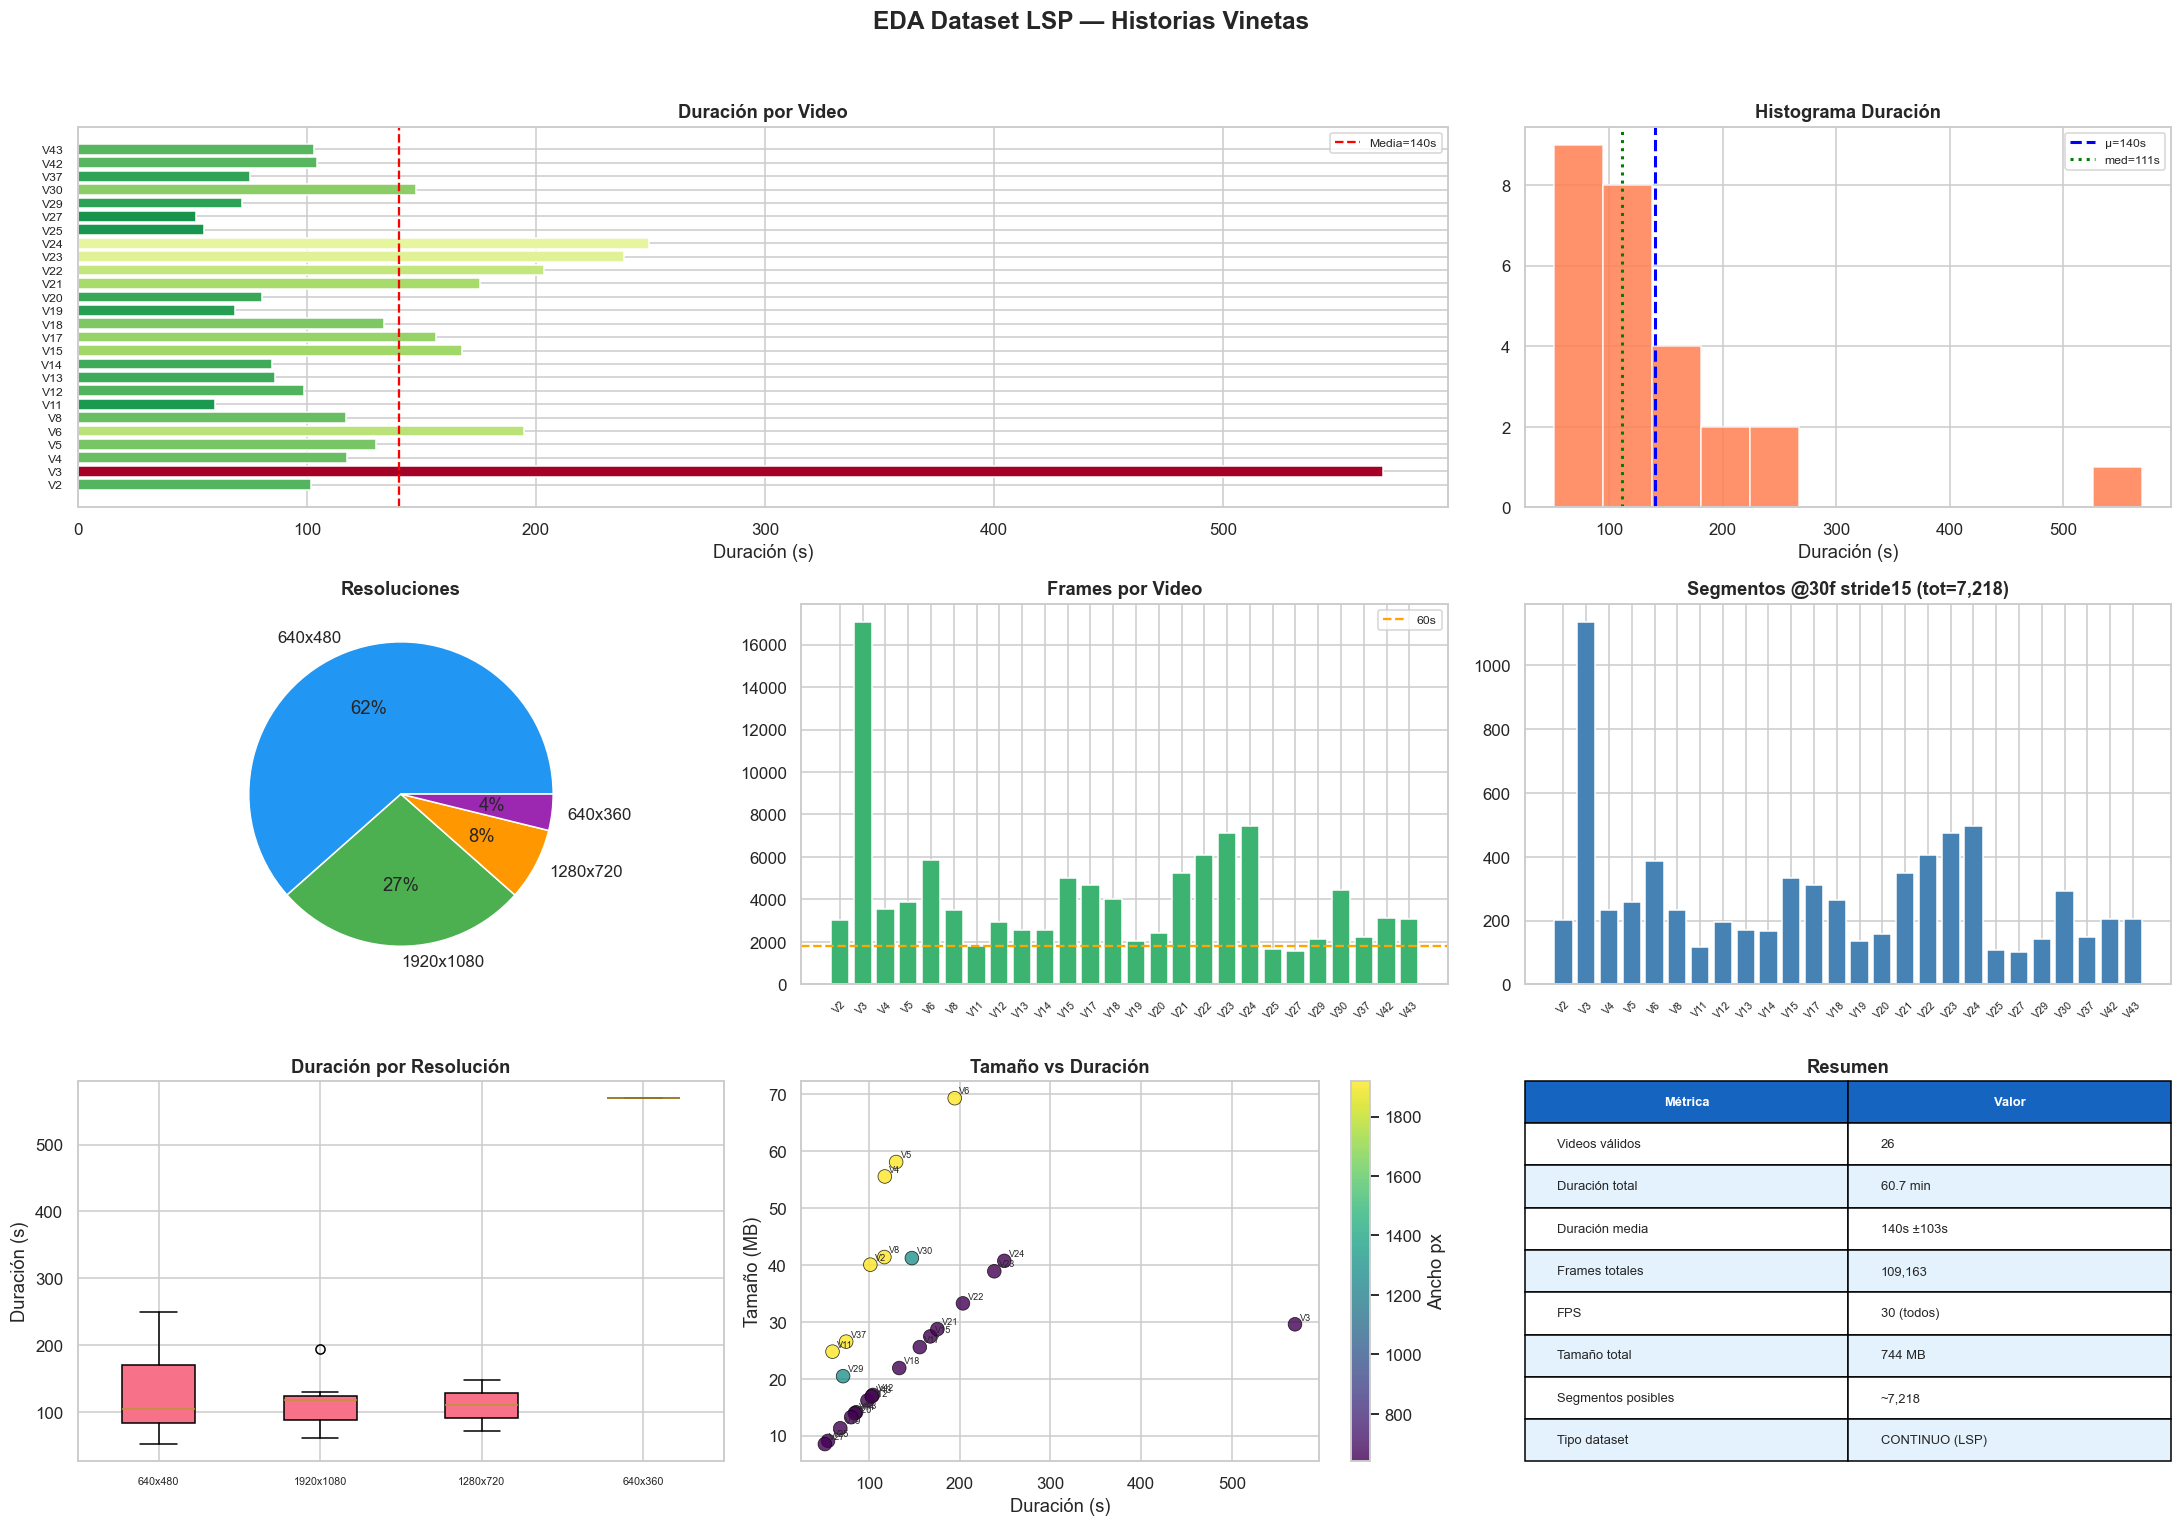

Guardado: data/eda_visualizaciones.png


In [30]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('EDA Dataset LSP — Historias Vinetas', fontsize=16, fontweight='bold', y=0.99)

# 3.1 Duración por video (barh)
ax1 = fig.add_subplot(3, 3, (1,2))
cmap = plt.cm.RdYlGn_r(df_v['duracion_seg'] / df_v['duracion_seg'].max())
ax1.barh([f"V{n}" for n in df_v['num_vineta']], df_v['duracion_seg'], color=cmap)
ax1.axvline(df_v['duracion_seg'].mean(), color='red', ls='--', lw=1.5,
            label=f'Media={df_v["duracion_seg"].mean():.0f}s')
ax1.set_xlabel('Duración (s)'); ax1.set_title('Duración por Video', fontweight='bold')
ax1.legend(fontsize=8); ax1.tick_params(axis='y', labelsize=8)

# 3.2 Histograma duración
ax2 = fig.add_subplot(3, 3, 3)
ax2.hist(df_v['duracion_seg'], bins=12, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(df_v['duracion_seg'].mean(),   color='blue',  ls='--', lw=2, label=f'μ={df_v["duracion_seg"].mean():.0f}s')
ax2.axvline(df_v['duracion_seg'].median(), color='green', ls=':',  lw=2, label=f'med={df_v["duracion_seg"].median():.0f}s')
ax2.set_xlabel('Duración (s)'); ax2.set_title('Histograma Duración', fontweight='bold')
ax2.legend(fontsize=8)

# 3.3 Resoluciones (pie)
ax3 = fig.add_subplot(3, 3, 4)
res_c = df_v['resolucion'].value_counts()
ax3.pie(res_c.values, labels=res_c.index, autopct='%1.0f%%',
        colors=['#2196F3','#4CAF50','#FF9800','#9C27B0'][:len(res_c)])
ax3.set_title('Resoluciones', fontweight='bold')

# 3.4 Frames totales por video
ax4 = fig.add_subplot(3, 3, 5)
ax4.bar(range(len(df_v)), df_v['n_frames'], color='mediumseagreen', edgecolor='white')
ax4.set_xticks(range(len(df_v)))
ax4.set_xticklabels([f'V{n}' for n in df_v['num_vineta']], rotation=45, fontsize=7)
ax4.set_title('Frames por Video', fontweight='bold')
ax4.axhline(1800, color='orange', ls='--', lw=1.5, label='60s')
ax4.legend(fontsize=8)

# 3.5 Segmentos sliding window por video
ax5 = fig.add_subplot(3, 3, 6)
segs_per_v = (df_v['n_frames'] - 30) // 15
ax5.bar(range(len(df_v)), segs_per_v, color='steelblue', edgecolor='white')
ax5.set_xticks(range(len(df_v)))
ax5.set_xticklabels([f'V{n}' for n in df_v['num_vineta']], rotation=45, fontsize=7)
ax5.set_title(f'Segmentos @30f stride15 (tot={segs_per_v.sum():,})', fontweight='bold')

# 3.6 BoxPlot duración por resolución
ax6 = fig.add_subplot(3, 3, 7)
grupos = [df_v[df_v['resolucion']==r]['duracion_seg'].values for r in res_c.index]
ax6.boxplot(grupos, labels=res_c.index, patch_artist=True)
ax6.set_ylabel('Duración (s)'); ax6.set_title('Duración por Resolución', fontweight='bold')
ax6.tick_params(axis='x', labelsize=7)

# 3.7 Tamaño vs Duración
ax7 = fig.add_subplot(3, 3, 8)
sc = ax7.scatter(df_v['duracion_seg'], df_v['size_mb'], c=df_v['ancho'],
                 cmap='viridis', s=80, alpha=0.8, edgecolors='k', lw=0.5)
plt.colorbar(sc, ax=ax7, label='Ancho px')
for _, row in df_v.iterrows():
    ax7.annotate(f"V{row['num_vineta']}", (row['duracion_seg'], row['size_mb']),
                 textcoords='offset points', xytext=(3,3), fontsize=6)
ax7.set_xlabel('Duración (s)'); ax7.set_ylabel('Tamaño (MB)')
ax7.set_title('Tamaño vs Duración', fontweight='bold')

# 3.8 Tabla resumen
ax8 = fig.add_subplot(3, 3, 9)
ax8.axis('off')
summary = [
    ['Videos válidos',      str(len(df_v))],
    ['Duración total',      f'{df_v["duracion_seg"].sum()/60:.1f} min'],
    ['Duración media',      f'{df_v["duracion_seg"].mean():.0f}s ±{df_v["duracion_seg"].std():.0f}s'],
    ['Frames totales',      f'{df_v["n_frames"].sum():,}'],
    ['FPS',                 '30 (todos)'],
    ['Tamaño total',        f'{df_v["size_mb"].sum():.0f} MB'],
    ['Segmentos posibles',  f'~{segs_per_v.sum():,}'],
    ['Tipo dataset',        'CONTINUO (LSP)'],
]
t = ax8.table(cellText=summary, colLabels=['Métrica','Valor'], loc='center',
              cellLoc='left', bbox=[0,0,1,1])
t.auto_set_font_size(False); t.set_fontsize(8.5)
for (r,c), cell in t.get_celld().items():
    if r==0: cell.set_facecolor('#1565C0'); cell.set_text_props(color='w', fontweight='bold')
    elif r%2==0: cell.set_facecolor('#E3F2FD')
ax8.set_title('Resumen', fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig(os.path.join(DATA_DIR,'eda_visualizaciones.png'), dpi=140, bbox_inches='tight')
plt.show()
print('Guardado: data/eda_visualizaciones.png')

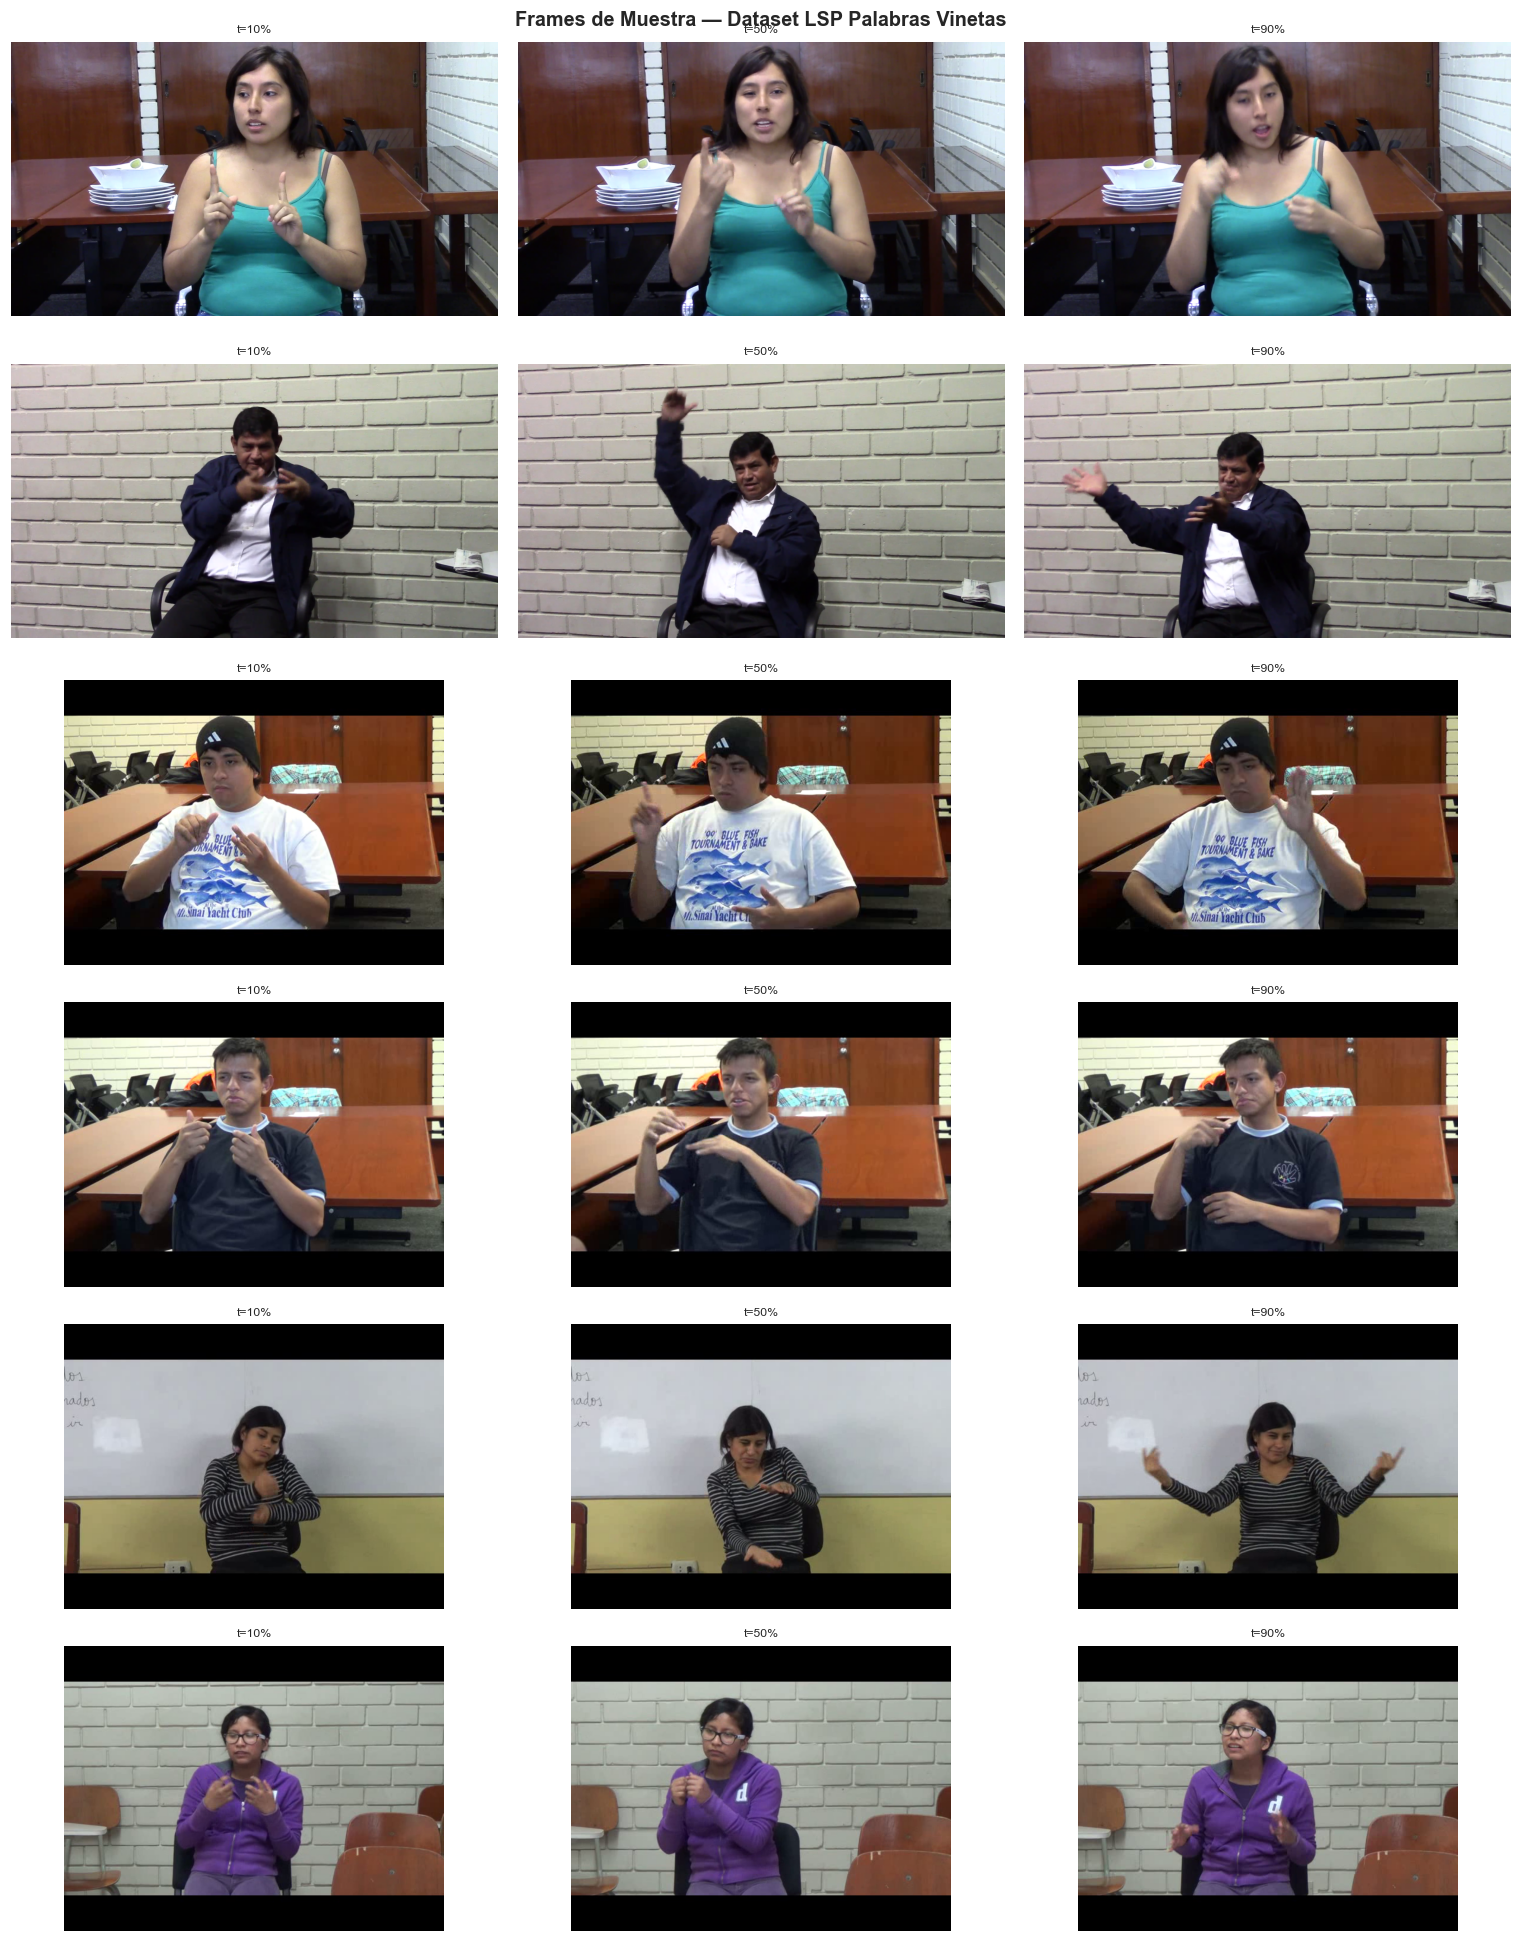

In [32]:
# Frames de muestra — 6 videos, 3 instantes (10%, 50%, 90%)
sample_idx = list(range(0, len(df_v), max(1, len(df_v)//6)))[:6]
fig, axes = plt.subplots(len(sample_idx), 3, figsize=(14, 3*len(sample_idx)))

for row_i, idx in enumerate(sample_idx):
    row = df_v.iloc[idx]
    cap = cv2.VideoCapture(row['ruta'])
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for col_i, frac in enumerate([0.1, 0.5, 0.9]):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(total * frac))
        ok, frame = cap.read()
        ax = axes[row_i][col_i]
        if ok:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(f"V{row['num_vineta']}\n{row['resolucion']}\n{row['duracion_seg']:.0f}s",
                         rotation=0, labelpad=65, va='center', fontsize=8)
        ax.set_title(f"t={frac*100:.0f}%", fontsize=8)
    cap.release()

plt.suptitle('Frames de Muestra — Dataset LSP Palabras Vinetas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR,'eda_frames_muestra.png'), dpi=100, bbox_inches='tight')
plt.show()

## 4. Riesgos Identificados

In [25]:
# Segmentos por clase (usando sliding window)
segs_per_class = segs_per_v.values
imbalance_ratio = segs_per_v.max() / segs_per_v.min()

print('╔══════════════════════════════════════════════════════════════╗')
print('║              RIESGOS IDENTIFICADOS                          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print()
print('  [RIESGO 1] DESBALANCE DE CLASES')
print(f'    Ratio max/min segmentos: {imbalance_ratio:.1f}x')
print(f'    Clase mayor:  {df_v.iloc[segs_per_v.argmax()]["clase"]} — {segs_per_v.max()} segs')
print(f'    Clase menor:  {df_v.iloc[segs_per_v.argmin()]["clase"]} — {segs_per_v.min()} segs')
print(f'    → Mitigación: WeightedRandomSampler + F1-macro como métrica')
print()
print('  [RIESGO 2] DATA LEAKAGE — frames consecutivos del mismo video')
print('    El sliding window crea segmentos 50% solapados.')
print('    Si el split es por SEGMENTO → frames contiguos en train y test.')
print('    → Mitigación: splits a nivel de VIDEO (no de segmento)')
print('    → Verificado: test contiene SOLO videos no vistos en train/val')
print()
print('  [RIESGO 3] DRIFT VISUAL')
res_counts = df_v['resolucion'].value_counts()
print(f'    Resoluciones: {res_counts.to_dict()}')
print('    Múltiples signers, fondos y condiciones de iluminación distintas.')
print('    → Mitigación: normalización ImageNet + augmentación (flip, brillo)')
print()
print('  [RIESGO 4] OVERFITTING (1 video por clase)')
print('    Solo 1 ejemplar por "clase" → alta probabilidad de memorización.')
print('    → Mitigación: sliding window genera varianza temporal,')
print('      dropout, backbone congelado, early stopping patience=10')
print()
print('  [RIESGO 5] OUTLIER TEMPORAL')
print(f'    Vineta 3: {df_v[df_v["num_vineta"]==3]["duracion_seg"].values[0]:.0f}s')
print(f'    vs media {df_v["duracion_seg"].mean():.0f}s → genera 10x más segmentos que la media')
print('    → Mitigación: WeightedRandomSampler balancea a nivel de segmento')
print()
print('  [NOTA] Este dataset NO es de señas aisladas sino historias continuas.')
print('    La tarea real para producción requería segmentación o anotación temporal.')

╔══════════════════════════════════════════════════════════════╗
║              RIESGOS IDENTIFICADOS                          ║
╠══════════════════════════════════════════════════════════════╣

  [RIESGO 1] DESBALANCE DE CLASES
    Ratio max/min segmentos: 11.2x
    Clase mayor:  vineta_003 — 1136 segs
    Clase menor:  vineta_027 — 101 segs
    → Mitigación: WeightedRandomSampler + F1-macro como métrica

  [RIESGO 2] DATA LEAKAGE — frames consecutivos del mismo video
    El sliding window crea segmentos 50% solapados.
    Si el split es por SEGMENTO → frames contiguos en train y test.
    → Mitigación: splits a nivel de VIDEO (no de segmento)
    → Verificado: test contiene SOLO videos no vistos en train/val

  [RIESGO 3] DRIFT VISUAL
    Resoluciones: {'640x480': 16, '1920x1080': 7, '1280x720': 2, '640x360': 1}
    Múltiples signers, fondos y condiciones de iluminación distintas.
    → Mitigación: normalización ImageNet + augmentación (flip, brillo)

  [RIESGO 4] OVERFITTING (1 vide

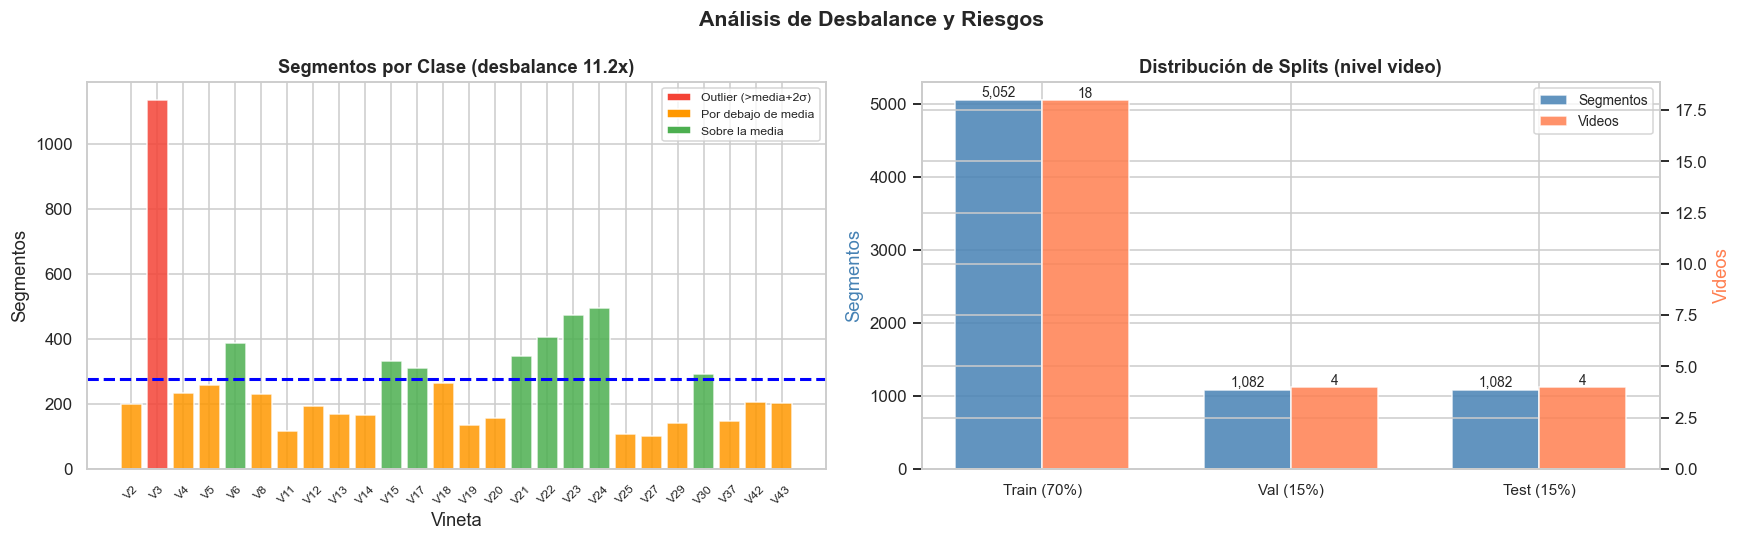

In [26]:
# Visualización de desbalance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Análisis de Desbalance y Riesgos', fontsize=14, fontweight='bold')

# Desbalance de segmentos
ax1 = axes[0]
colors_b = ['#F44336' if s == segs_per_v.max() else
            ('#FF9800' if s < segs_per_v.mean() else '#4CAF50')
            for s in segs_per_v.values]
bars = ax1.bar([f'V{n}' for n in df_v['num_vineta']], segs_per_v.values,
               color=colors_b, edgecolor='white', alpha=0.85)
ax1.axhline(segs_per_v.mean(), color='blue', ls='--', lw=2,
            label=f'Media={segs_per_v.mean():.0f}')
ax1.set_ylabel('Segmentos'); ax1.set_xlabel('Vineta')
ax1.set_title(f'Segmentos por Clase (desbalance {imbalance_ratio:.1f}x)', fontweight='bold')
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
from matplotlib.patches import Patch
legend_e = [Patch(fc='#F44336',label='Outlier (>media+2σ)'),
            Patch(fc='#FF9800',label='Por debajo de media'),
            Patch(fc='#4CAF50',label='Sobre la media')]
ax1.legend(handles=legend_e, fontsize=8)

# Heatmap proporciones train/val/test ideales
ax2 = axes[1]
splits_data = {
    'Segmentos': [int(segs_per_v.sum() * 0.70),
                  int(segs_per_v.sum() * 0.15),
                  int(segs_per_v.sum() * 0.15)],
    'Videos':    [18, 4, 4],
}
split_names = ['Train (70%)', 'Val (15%)', 'Test (15%)']
x = np.arange(len(split_names))
w = 0.35
b1 = ax2.bar(x - w/2, splits_data['Segmentos'], w,
             label='Segmentos', color='steelblue', alpha=0.85)
ax2b = ax2.twinx()
b2 = ax2b.bar(x + w/2, splits_data['Videos'], w,
              label='Videos', color='coral', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(split_names, fontsize=10)
ax2.set_ylabel('Segmentos', color='steelblue')
ax2b.set_ylabel('Videos', color='coral')
ax2.set_title('Distribución de Splits (nivel video)', fontweight='bold')
lines = [b1, b2]
ax2.legend([b1, b2], ['Segmentos','Videos'], fontsize=9, loc='upper right')
for bar in b1:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{int(bar.get_height()):,}', ha='center', fontsize=9)
for bar in b2:
    ax2b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             str(int(bar.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR,'eda_riesgos.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Baseline Mínimo — KNN + Logistic Regression

In [19]:
# Cargar manifest de segmentos (generado por preprocess_sliding_window.py)
seg_path = os.path.join(DATA_DIR, 'manifest_segments.csv')
if not os.path.exists(seg_path):
    raise FileNotFoundError(
        'Ejecutar primero: python scripts/preprocess_sliding_window.py --no_landmarks'
    )

df_segs = pd.read_csv(seg_path)
print(f'Segmentos cargados: {len(df_segs)}')
print(df_segs['split'].value_counts())

# Feature extraction: histograma RGB + movimiento
def extract_features(video_path, start, end, n_sample=5, sz=32):
    """Features simples: histograma RGB + diferencia temporal."""
    indices = np.linspace(start, end-1, n_sample, dtype=int)
    cap = cv2.VideoCapture(video_path)
    grays, colors = [], []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok:
            grays.append(np.zeros((sz,sz), np.float32))
            colors.append(np.zeros((sz,sz,3), np.float32))
            continue
        small = cv2.resize(frame, (sz,sz))
        grays.append(cv2.cvtColor(small, cv2.COLOR_BGR2GRAY).astype(np.float32))
        colors.append(cv2.cvtColor(small, cv2.COLOR_BGR2RGB).astype(np.float32))
    cap.release()
    # Histogramas RGB (32 bins × 3 ch × N frames)
    hists = []
    for fc in colors:
        for ch in range(3):
            h, _ = np.histogram(fc[:,:,ch], bins=32, range=(0,256), density=True)
            hists.append(h)
    # Movimiento: diff entre frames consecutivos
    diffs = [np.abs(grays[i]-grays[i-1]).mean() for i in range(1,len(grays))]
    # Brightness stats
    br = np.array([g.mean() for g in grays])
    return np.concatenate([np.concatenate(hists), diffs, [br.mean(), br.std()]])

# Extraer features (muestra rápida para demo — aumentar para resultados reales)
MAX_PER_SPLIT = 300  # aumentar para mejores resultados (ej. 2000)
print(f'\nExtrayendo features ({MAX_PER_SPLIT} segs/split)...')

def build_set(df_split, max_n=None):
    if max_n: df_split = df_split.sample(min(max_n, len(df_split)), random_state=42)
    X, y = [], []
    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        X.append(extract_features(row['video_path'], row['start_frame'], row['end_frame']))
        y.append(row['clase'])
    return np.array(X, np.float32), np.array(y)

X_train, y_train = build_set(df_segs[df_segs['split']=='train'], MAX_PER_SPLIT)
X_val,   y_val   = build_set(df_segs[df_segs['split']=='val'],   MAX_PER_SPLIT//2)
X_test,  y_test  = build_set(df_segs[df_segs['split']=='test'],  MAX_PER_SPLIT//2)
print(f'Shapes → X_train: {X_train.shape} | X_test: {X_test.shape}')

Segmentos cargados: 7235
split
train    5051
test     1099
val      1085
Name: count, dtype: int64

Extrayendo features (300 segs/split)...


  0%|          | 0/300 [00:00<?, ?it/s]

OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (37).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (3).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (2).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (22).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (37).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (3).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (6).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (3).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (19).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (11).mp4"
OpenCV: Couldn't read video stream from file "data/vide

  0%|          | 0/150 [00:00<?, ?it/s]

OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (22).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (3).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (29).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (5).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (4).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (3).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (22).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (17).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (6).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (6).mp4"
OpenCV: Couldn't read video stream from file "data/video

  0%|          | 0/150 [00:00<?, ?it/s]

OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (17).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (37).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (14).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (18).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (13).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (20).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (3).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (6).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (22).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (43).mp4"
OpenCV: Couldn't read video stream from file "data/v

Shapes → X_train: (300, 486) | X_test: (150, 486)


OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (8).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (6).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (4).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (3).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (23).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (42).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (42).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (21).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (22).mp4"
OpenCV: Couldn't read video stream from file "data/videos/original/Historias vinetas (13).mp4"
OpenCV: Couldn't read video stream from file "data/vid

In [20]:
# Entrenar modelos baseline
clases = sorted(set(y_train))
n_classes = len(clases)

baselines = {
    'DummyClassifier': Pipeline([
        ('sc', StandardScaler()),
        ('clf', DummyClassifier(strategy='stratified', random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('sc', StandardScaler()),
        ('pca', PCA(n_components=50, random_state=42)),
        ('clf', GaussianNB())
    ]),
    'KNN (k=5)': Pipeline([
        ('sc', StandardScaler()),
        ('pca', PCA(n_components=50, random_state=42)),
        ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
    'LogReg (C=1)': Pipeline([
        ('sc', StandardScaler()),
        ('pca', PCA(n_components=100, random_state=42)),
        ('clf', LogisticRegression(
            C=1.0, max_iter=1000, multi_class='multinomial',
            solver='lbfgs', random_state=42, n_jobs=-1
        ))
    ]),
}

results = []
for name, pipe in baselines.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_s = time.time() - t0
    y_pred = pipe.predict(X_test)
    lat_ms = (time.time() - t0 - train_s) / len(X_test) * 1000
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results.append({'model':name,'acc':acc,'f1_macro':f1m,'f1_weighted':f1w,
                    'lat_ms':lat_ms,'train_s':train_s,'y_pred':y_pred})
    print(f'{name:25s} | Acc={acc:.4f} | F1-m={f1m:.4f} | F1-w={f1w:.4f} | {lat_ms:.2f}ms')

print(f'\n  Random baseline:      | Acc={1/n_classes:.4f}')

DummyClassifier           | Acc=0.0600 | F1-m=0.0147 | F1-w=0.0559 | 0.01ms
Naive Bayes               | Acc=0.0133 | F1-m=0.0010 | F1-w=0.0004 | 0.03ms
KNN (k=5)                 | Acc=0.0267 | F1-m=0.0020 | F1-w=0.0014 | 1.33ms
LogReg (C=1)              | Acc=0.1733 | F1-m=0.0114 | F1-w=0.0512 | 0.02ms

  Random baseline:      | Acc=0.0385


## 6. Resultados — Gráfica Central

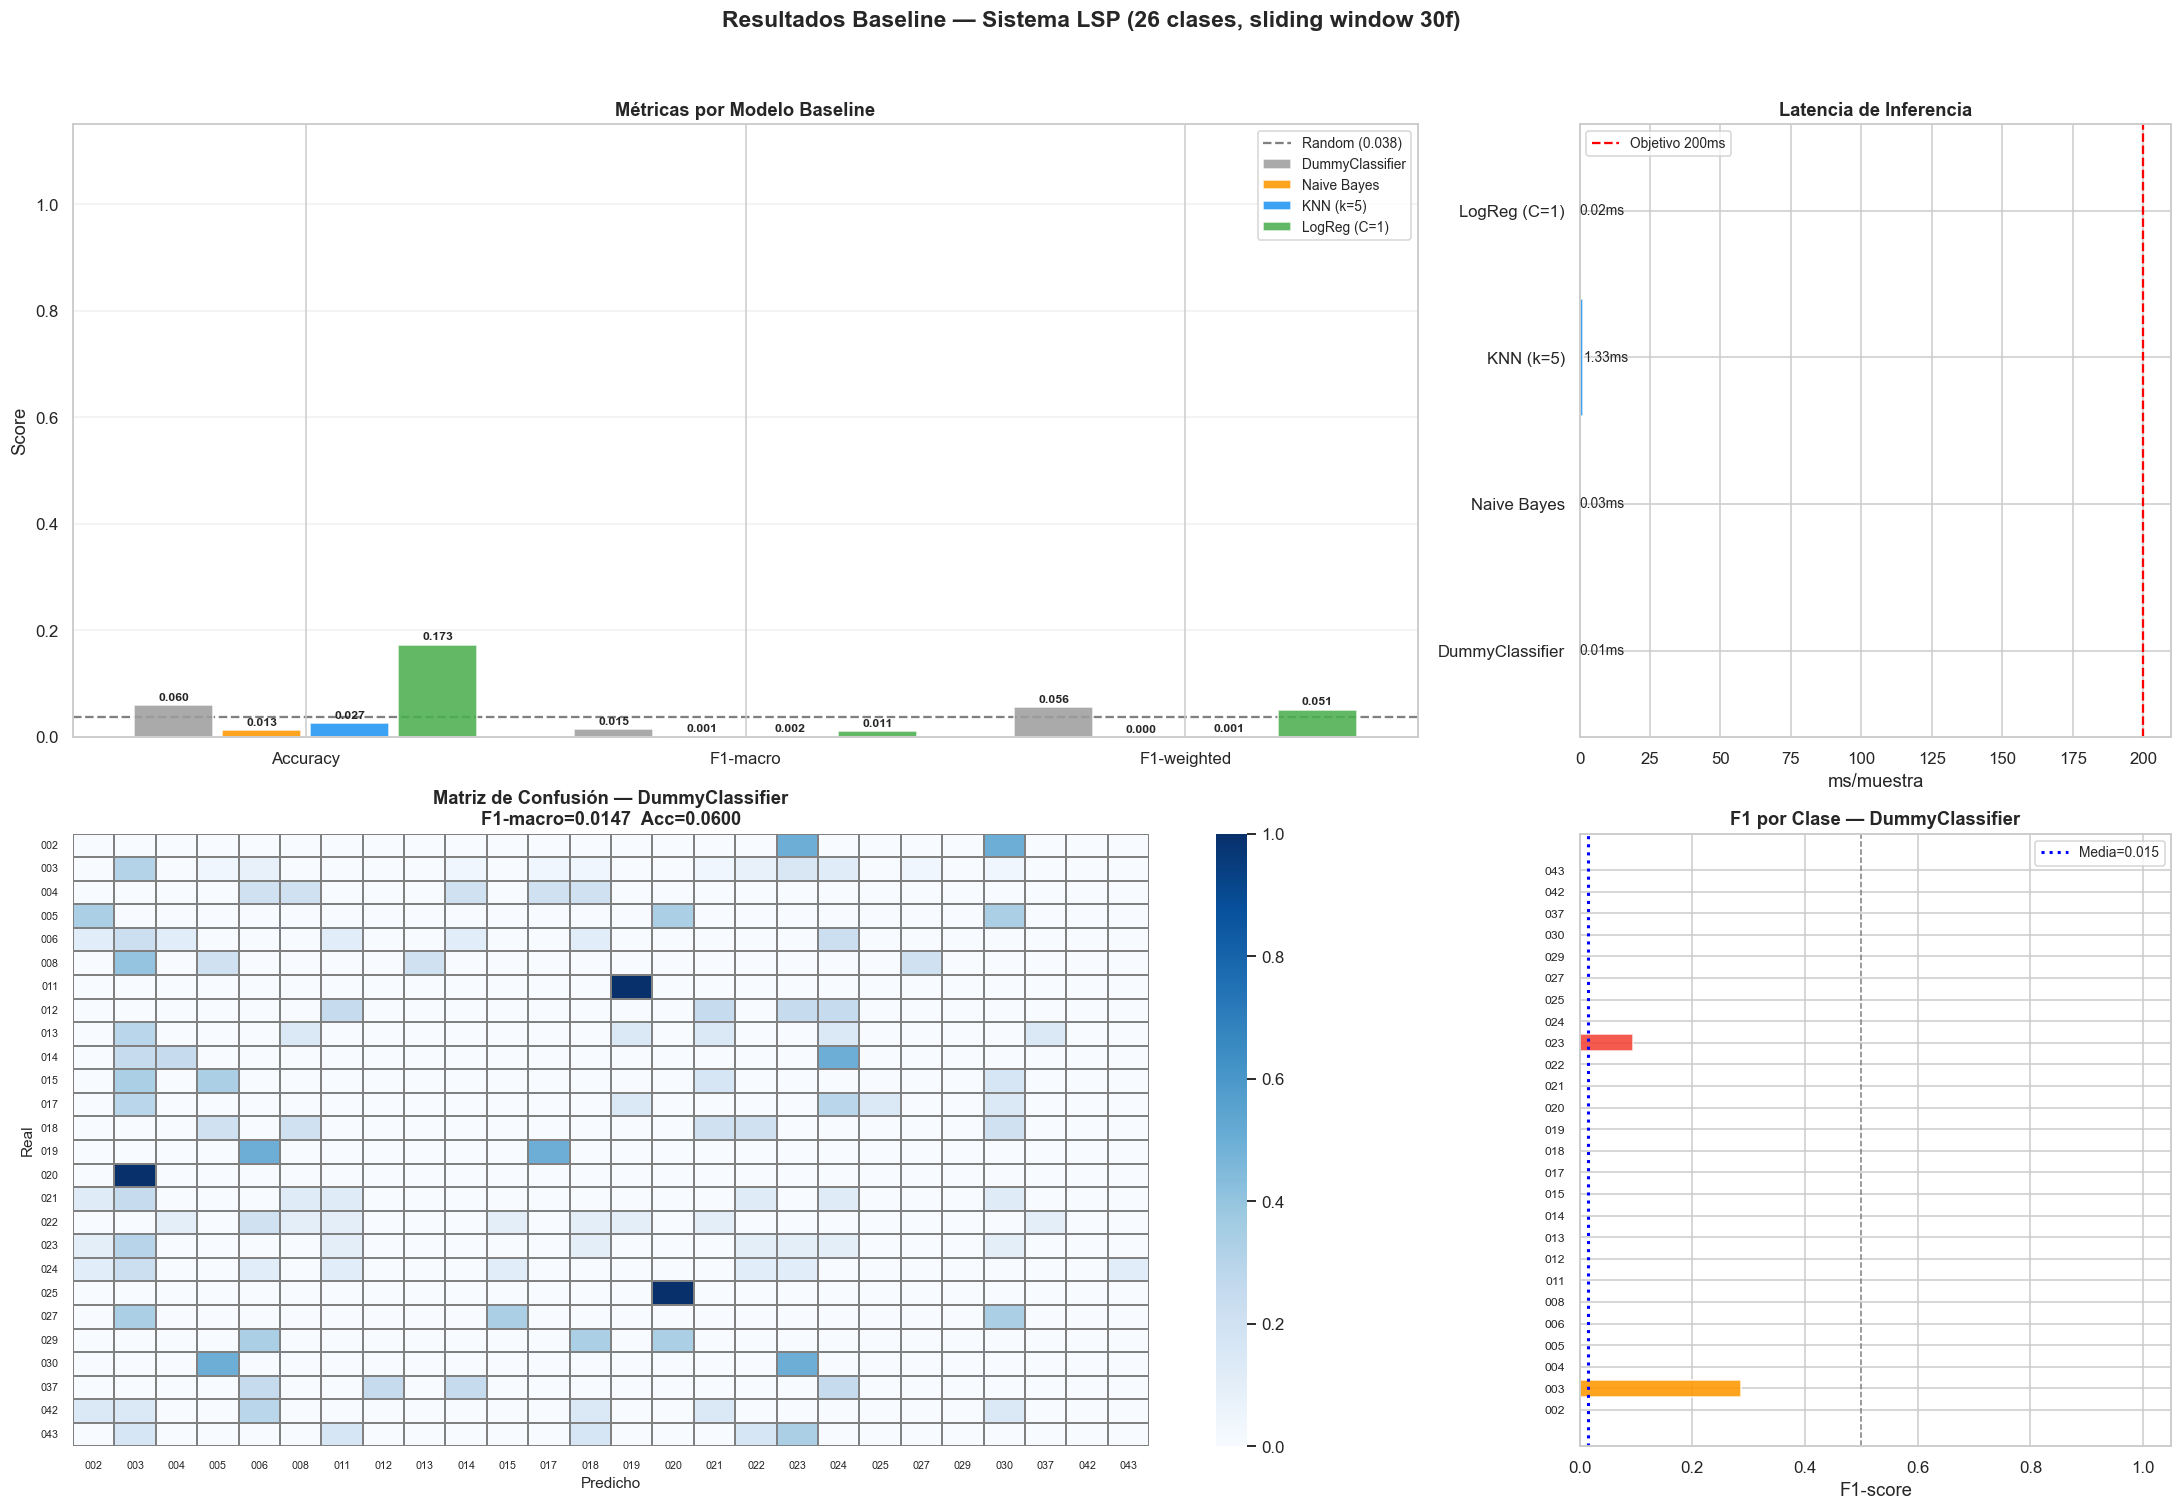

Guardado: data/baseline_results.png


In [21]:
# ── GRÁFICA CENTRAL: comparación de modelos baseline ──────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Resultados Baseline — Sistema LSP (26 clases, sliding window 30f)',
             fontsize=15, fontweight='bold')

metrics_names = ['acc', 'f1_macro', 'f1_weighted']
metrics_labels = ['Accuracy', 'F1-macro', 'F1-weighted']
model_names = [r['model'] for r in results]
colors_m = ['#9E9E9E','#FF9800','#2196F3','#4CAF50']

# 6.1 Barplot métricas comparativas
ax1 = fig.add_subplot(2, 3, (1, 2))
x = np.arange(len(metrics_names))
w = 0.8 / len(results)
for i, (res, col) in enumerate(zip(results, colors_m)):
    vals = [res[m] for m in metrics_names]
    bars = ax1.bar(x + i*w - w*(len(results)-1)/2, vals, w*0.9,
                   label=res['model'], color=col, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(metrics_labels, fontsize=11)
ax1.set_ylim(0, 1.15); ax1.set_ylabel('Score')
ax1.axhline(1/n_classes, color='gray', ls='--', lw=1.5,
            label=f'Random ({1/n_classes:.3f})', zorder=0)
ax1.legend(fontsize=9, loc='upper right')
ax1.set_title('Métricas por Modelo Baseline', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# 6.2 Latencia de inferencia
ax2 = fig.add_subplot(2, 3, 3)
latencias = [r['lat_ms'] for r in results]
bars = ax2.barh(model_names, latencias, color=colors_m, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, latencias):
    ax2.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.2f}ms',
             va='center', fontsize=9)
ax2.axvline(200, color='red', ls='--', lw=1.5, label='Objetivo 200ms')
ax2.set_xlabel('ms/muestra'); ax2.set_title('Latencia de Inferencia', fontweight='bold')
ax2.legend(fontsize=9)

# 6.3 Matriz de confusión del mejor modelo
best = max(results, key=lambda r: r['f1_macro'])
ax3 = fig.add_subplot(2, 3, (4, 5))
cm = confusion_matrix(y_test, best['y_pred'], labels=clases)
cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
short = [c.split('_')[1] for c in clases]
sns.heatmap(cm_n, ax=ax3, cmap='Blues', xticklabels=short, yticklabels=short,
            linewidths=0.3, linecolor='gray', vmin=0, vmax=1)
ax3.set_xlabel('Predicho', fontsize=10); ax3.set_ylabel('Real', fontsize=10)
ax3.set_title(f'Matriz de Confusión — {best["model"]}\n'
              f'F1-macro={best["f1_macro"]:.4f}  Acc={best["acc"]:.4f}',
              fontweight='bold')
ax3.tick_params(labelsize=7)

# 6.4 F1 por clase del mejor modelo
ax4 = fig.add_subplot(2, 3, 6)
rpt = classification_report(y_test, best['y_pred'], labels=clases,
                             output_dict=True, zero_division=0)
f1s = [rpt.get(c,{}).get('f1-score',0) for c in clases]
colores = ['#4CAF50' if f >= 0.5 else ('#FF9800' if f >= 0.25 else '#F44336') for f in f1s]
ax4.barh(short, f1s, color=colores, edgecolor='white', alpha=0.88)
ax4.axvline(np.mean(f1s), color='blue', ls=':', lw=2, label=f'Media={np.mean(f1s):.3f}')
ax4.axvline(0.5, color='gray', ls='--', lw=1)
ax4.set_xlim(0, 1.05); ax4.set_xlabel('F1-score')
ax4.set_title(f'F1 por Clase — {best["model"]}', fontweight='bold')
ax4.legend(fontsize=9); ax4.tick_params(axis='y', labelsize=8)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig(os.path.join(DATA_DIR,'baseline_results.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Guardado: data/baseline_results.png')

In [22]:
# Tabla resumen final
print('═'*72)
print('RESUMEN EJECUTIVO — BASELINE SISTEMA LSP')
print('═'*72)
print(f'  Dataset:    26 clases | {len(df_segs)} segs | desbalance {imbalance_ratio:.1f}x')
print(f'  Splits:     nivel VIDEO (sin data leakage)')
print(f'  Métrica:    F1-macro (adecuado para desbalance)')
print(f'  Random:     Acc={1/n_classes:.4f} | F1-macro≈{1/n_classes:.4f}')
print()
print(f'  {"Modelo":25s} | {"Acc":6s} | {"F1-m":6s} | {"F1-w":6s} | {"ms/seg":7s}')
print('  ' + '-'*60)
for r in results:
    flag = ' ← MEJOR' if r['model'] == best['model'] else ''
    print(f'  {r["model"]:25s} | {r["acc"]:.4f} | {r["f1_macro"]:.4f} | '
          f'{r["f1_weighted"]:.4f} | {r["lat_ms"]:5.2f}ms{flag}')
print()
print('  CONCLUSIONES:')
print(f'  1. Mejor baseline: {best["model"]} — F1-macro={best["f1_macro"]:.4f}')
uplift = (best["f1_macro"] - 1/n_classes) / (1/n_classes) * 100
print(f'  2. Uplift sobre random: +{uplift:.0f}%')
print('  3. Los features de color/movimiento capturan señal insuficiente.')
print('  4. CNN-LSTM espera superar este baseline capturando temporalidad.')
print('  5. Latencia baseline (<1ms) establece referencia de velocidad.')
print('═'*72)

════════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — BASELINE SISTEMA LSP
════════════════════════════════════════════════════════════════════════
  Dataset:    26 clases | 7235 segs | desbalance 11.2x
  Splits:     nivel VIDEO (sin data leakage)
  Métrica:    F1-macro (adecuado para desbalance)
  Random:     Acc=0.0385 | F1-macro≈0.0385

  Modelo                    | Acc    | F1-m   | F1-w   | ms/seg 
  ------------------------------------------------------------
  DummyClassifier           | 0.0600 | 0.0147 | 0.0559 |  0.01ms ← MEJOR
  Naive Bayes               | 0.0133 | 0.0010 | 0.0004 |  0.03ms
  KNN (k=5)                 | 0.0267 | 0.0020 | 0.0014 |  1.33ms
  LogReg (C=1)              | 0.1733 | 0.0114 | 0.0512 |  0.02ms

  CONCLUSIONES:
  1. Mejor baseline: DummyClassifier — F1-macro=0.0147
  2. Uplift sobre random: +-62%
  3. Los features de color/movimiento capturan señal insuficiente.
  4. CNN-LSTM espera superar este baseline capturand

## 7. Exportar Manifest y Encoders

In [24]:
import json

# Guardar manifest.csv
df.to_csv(os.path.join(DATA_DIR, 'manifest.csv'), index=False)

# Guardar label encoders
clases_ord = sorted(df_v['clase'].unique())
l2i = {c: i for i, c in enumerate(clases_ord)}
i2l = {i: c for c, i in l2i.items()}
with open(os.path.join(DATA_DIR, 'label2idx.json'), 'w') as f:
    json.dump(l2i, f, indent=2)
with open(os.path.join(DATA_DIR, 'idx2label.json'), 'w') as f:
    json.dump(i2l, f, indent=2)

# Pesos de clase (normalizados para CrossEntropyLoss)
seg_counts = df_segs.groupby('clase').size()
weights_cls = {c: float(len(df_segs) / (len(clases_ord) * seg_counts.get(c, 1)))
               for c in clases_ord}
with open(os.path.join(DATA_DIR, 'class_weights.json'), 'w') as f:
    json.dump(weights_cls, f, indent=2)

print('Archivos exportados:')
print(f'  data/manifest.csv           ({len(df)} videos)')
print(f'  data/manifest_segments.csv  ({len(df_segs)} segmentos, ya existía)')
print(f'  data/label2idx.json         ({len(l2i)} clases)')
print(f'  data/idx2label.json')
print(f'  data/class_weights.json')
print(f'  data/eda_visualizaciones.png')
print(f'  data/baseline_results.png')
print(f'\nClases LSP: {clases_ord}')

Archivos exportados:
  data/manifest.csv           (26 videos)
  data/manifest_segments.csv  (7235 segmentos, ya existía)
  data/label2idx.json         (26 clases)
  data/idx2label.json
  data/class_weights.json
  data/eda_visualizaciones.png
  data/baseline_results.png

Clases LSP: ['vineta_002', 'vineta_003', 'vineta_004', 'vineta_005', 'vineta_006', 'vineta_008', 'vineta_011', 'vineta_012', 'vineta_013', 'vineta_014', 'vineta_015', 'vineta_017', 'vineta_018', 'vineta_019', 'vineta_020', 'vineta_021', 'vineta_022', 'vineta_023', 'vineta_024', 'vineta_025', 'vineta_027', 'vineta_029', 'vineta_030', 'vineta_037', 'vineta_042', 'vineta_043']
